# Uruti AI Incubator: Foundational Advisory Model Training Pipeline

This notebook represents the core model training and evaluation pipeline for the Uruti AI-powered incubator. The objective is to fine-tune a selection of state-of-the-art Large Language Models (LLMs) to provide localized, high-tier advisory services for tech founders in the Rwandan ecosystem.

## Pipeline Architecture
1. **Multimodal Ingestion Setup:** Preparation of functions to handle text, PDF, DOCX, and Audio (via Whisper) inputs.
2. **Dataset Curation & Visualization:** Upsampling proprietary ecosystem data and visualizing the distribution against general instruction datasets.
3. **High-Throughput Fine-Tuning:** Sequentially training 5 candidate models using QLoRA, optimized for A100 GPU architecture to prevent memory constraints.
4. **Performance Benchmarking:** Visualizing the evaluation loss across all candidates to quantitatively select the most capable model.
5. **Model Bundling & Export:** Physically merging the winning LoRA adapter into its base weights, generating integration documentation, and compiling a downloadable artifact for backend deployment.

### Environment setup

In [ ]:
# CELL 1: RUN THIS FIRST, THEN RESTART RUNTIME
!pip install -q -U transformers accelerate bitsandbytes peft trl datasets pypdf python-docx openai-whisper matplotlib seaborn pandas scipy langchain-community langchain-huggingface faiss-cpu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 57.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 120.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.7/520.7 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.4/331.4 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 27

In [ ]:
# 1. Install Dependencies

import os
import gc
import json
import random
import shutil
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from trl import SFTTrainer, SFTConfig

# 2. Google Colab Specific Integrations
try:
    from google.colab import drive, userdata
    IN_COLAB = True

    # Mount Google Drive permanently
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Retrieve Hugging Face Token from Colab Secrets
    try:
        hf_token = userdata.get('HF_TOKEN')
        os.environ['HF_TOKEN'] = hf_token
        print("✅ Hugging Face Token successfully loaded from Colab Secrets.")
    except Exception as e:
        raise ValueError("❌ HF_TOKEN not found in Colab Secrets. Please add it via the 🔑 icon on the left sidebar.")

except ImportError:
    IN_COLAB = False
    print("Not running in Google Colab. Ensure HF_TOKEN is set in your environment variables.")

# 3. Hardware Verification
if not torch.cuda.is_available():
    raise RuntimeError("CRITICAL ERROR: GPU not detected. Please initialize an A100 runtime.")
print(f"✅ Hardware Verified: {torch.cuda.get_device_name(0)}")

# 4. Directory Architecture Setup (Now saving directly to Google Drive!)
if IN_COLAB:
    # Save everything directly to Drive so it survives runtime disconnects
    PROJECT_DIR = Path("/content/drive/MyDrive/uruti_model_pipeline")
else:
    PROJECT_DIR = Path("./uruti_model_pipeline")

DATA_DIR = PROJECT_DIR / "data"
ADAPTER_BASE_DIR = PROJECT_DIR / "adapters"
FINAL_MODEL_DIR = PROJECT_DIR / "uruti_production_model"
EXPORT_DIR = PROJECT_DIR / "exports"

# Create directories if they don't exist
for directory in [DATA_DIR, ADAPTER_BASE_DIR, FINAL_MODEL_DIR, EXPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

sns.set_theme(style="whitegrid")
print(f"Environment setup complete. All files will be saved to: {PROJECT_DIR}")

Mounting Google Drive...
Mounted at /content/drive
✅ Hugging Face Token successfully loaded from Colab Secrets.
✅ Hardware Verified: NVIDIA A100-SXM4-80GB
Environment setup complete. All files will be saved to: /content/drive/MyDrive/uruti_model_pipeline


## 1. Multimodal Ingestion Handlers
The Uruti advisory system is designed to process diverse inputs from founders, including pitch decks, financial documents, and voice notes. The following functions establish the ingestion logic that the ultimate backend will utilize to parse these inputs into the model's context window.

### Ingestion Utilities

In [ ]:
import pypdf
import docx
import whisper

def ingest_document(path: str) -> str:
    """Extracts raw text from PDF, DOCX, or CSV files."""
    path_obj = Path(path)
    suffix = path_obj.suffix.lower()

    try:
        if suffix == '.pdf':
            reader = pypdf.PdfReader(str(path_obj))
            return '\n'.join((page.extract_text() or '') for page in reader.pages)
        elif suffix == '.docx':
            doc = docx.Document(str(path_obj))
            return '\n'.join(par.text for par in doc.paragraphs)
        elif suffix == '.csv':
            return pd.read_csv(path_obj).to_csv(index=False)
        else:
            raise ValueError(f"Unsupported document format: {suffix}")
    except Exception as e:
        print(f"Error reading {path_obj.name}: {e}")
        return ""

def ingest_audio(path: str) -> str:
    """Transcribes audio using OpenAI's Whisper, aggressively managing VRAM."""
    print(f"Transcribing: {path}...")
    model = whisper.load_model('base', device="cuda")
    result = model.transcribe(str(path))

    # Immediately clear VRAM to prevent interference with LLM training
    del model
    gc.collect()
    torch.cuda.empty_cache()

    return (result.get('text') or '').strip()

print("Ingestion modules initialized successfully.")

Ingestion modules initialized successfully.


## 2. Dataset Preparation & Upsampling
To ensure the resulting models prioritize the specific nuances of the Rwandan startup ecosystem, the proprietary advisory dataset is upsampled. This section prepares the training corpus and visualizes the distribution to verify data balance before fine-tuning commences.

### Data Loading & Visualization

🚀 Initializing Multi-Dataset Blending Pipeline...
✅ Uruti Data Loaded & Upsampled (30 rows)
📥 Streaming Dolly-15k (Information Extraction)...


README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

Filter:   0%|          | 0/15011 [00:00<?, ? examples/s]

...

📥 Streaming Finance-Specific Tasks...


README.md:   0%|          | 0.00/831 [00:00<?, ?B/s]

Cleaned_date.json:   0%|          | 0.00/42.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/68912 [00:00<?, ? examples/s]

🔀 Merging and shuffling datasets...


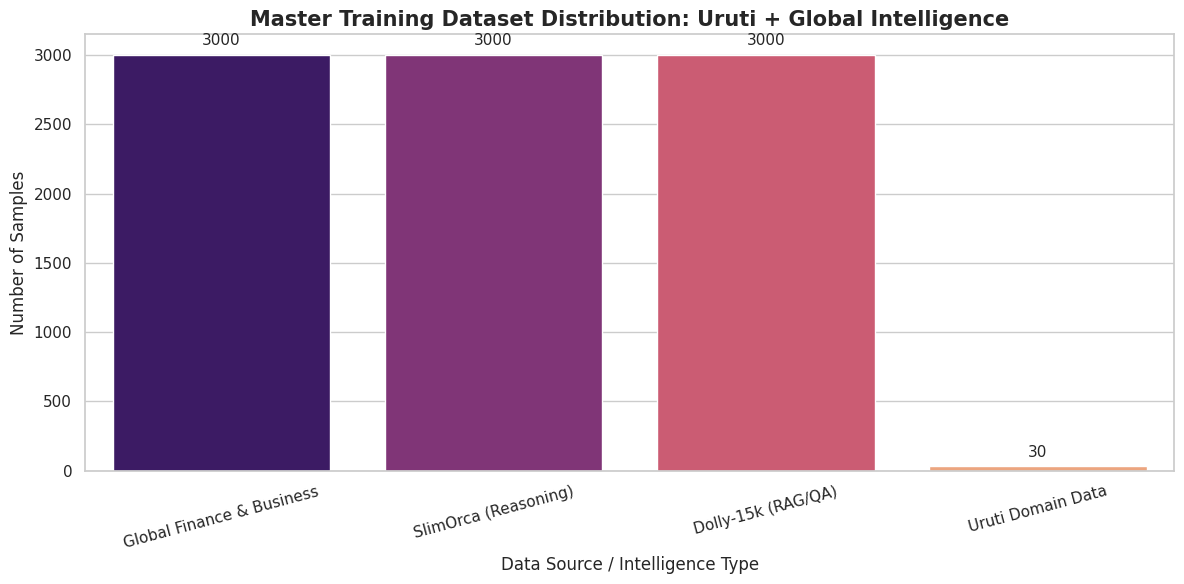

✅ Master Dataset Ready! Total Training Samples: 8127 | Evaluation Samples: 903


In [ ]:
# ==========================================
# CELL 3: DATA PREPARATION & MULTI-DATASET BLENDING
# ==========================================
import json
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset, load_dataset

print("🚀 Initializing Multi-Dataset Blending Pipeline...")

CHATBOT_DATA_PATH = DATA_DIR / "chatbot-data.json"

# 1. Load custom Uruti Data
try:
    with open(CHATBOT_DATA_PATH, 'r', encoding='utf-8') as f:
        chatbot_data = json.load(f)
except FileNotFoundError:
    raise FileNotFoundError(f"⚠️ Could not find {CHATBOT_DATA_PATH}. Please upload your Uruti JSON to Google Drive.")

# Format and heavily upsample Uruti Data
# A 30x multiplier ensures the model doesn't forget Rwanda while learning global finance
UPSAMPLE_MULTIPLIER = 30
uruti_data_formatted = [
    {"source": "Uruti Domain Data", "instruction": d['instruction'], "output": d['output']}
    for d in chatbot_data
]
upsampled_uruti_data = uruti_data_formatted * UPSAMPLE_MULTIPLIER
print(f"✅ Uruti Data Loaded & Upsampled ({len(upsampled_uruti_data)} rows)")

# 2. Stream Databricks Dolly-15k (For Anti-Hallucination & RAG)
print("📥 Streaming Dolly-15k (Information Extraction)...")
dolly_dataset = load_dataset("databricks/databricks-dolly-15k", split="train")
allowed_categories = ["closed_qa", "information_extraction", "brainstorming"]
dolly_filtered = dolly_dataset.filter(lambda x: x["category"] in allowed_categories)

dolly_data_formatted = []
for entry in dolly_filtered:
    instruct = f"Context:\n{entry['context']}\n\nQuestion:\n{entry['instruction']}" if entry.get('context') else entry['instruction']
    dolly_data_formatted.append({
        "source": "Dolly-15k (RAG/QA)",
        "instruction": instruct.strip(),
        "output": entry['response'].strip()
    })
dolly_sample = random.sample(dolly_data_formatted, min(3000, len(dolly_data_formatted)))

# 3. Stream SlimOrca (For Step-by-Step Strategic Reasoning)
# We only stream the first 5% to save massive download times
print("📥 Streaming SlimOrca (Strategic Reasoning)...")
orca_dataset = load_dataset("Open-Orca/SlimOrca-Dedup", split="train[:5%]")

orca_data_formatted = []
for entry in orca_dataset:
    conversations = entry.get("conversations", [])
    if len(conversations) >= 2:
        # Extract the human prompt and the GPT/Orca reasoning output
        user_text = next((msg["value"] for msg in conversations if msg["from"] == "human"), "")
        bot_text = next((msg["value"] for msg in conversations if msg["from"] == "gpt"), "")
        if user_text and bot_text:
            orca_data_formatted.append({
                "source": "SlimOrca (Reasoning)",
                "instruction": user_text.strip(),
                "output": bot_text.strip()
            })
orca_sample = random.sample(orca_data_formatted, min(3000, len(orca_data_formatted)))

# 4. Stream Finance/Business Tasks (For Equity, SAFEs, Valuations)
print("📥 Streaming Finance-Specific Tasks...")
finance_dataset = load_dataset("gbharti/finance-alpaca", split="train")

finance_data_formatted = []
for entry in finance_dataset:
    instruct = f"{entry['instruction']}\n{entry.get('input', '')}".strip()
    finance_data_formatted.append({
        "source": "Global Finance & Business",
        "instruction": instruct,
        "output": entry['output'].strip()
    })
finance_sample = random.sample(finance_data_formatted, min(3000, len(finance_data_formatted)))

# 5. Combine and Shuffle
print("🔀 Merging and shuffling datasets...")
combined_raw_data = upsampled_uruti_data + dolly_sample + orca_sample + finance_sample
random.shuffle(combined_raw_data)

dataset = Dataset.from_list(combined_raw_data)
split_dataset = dataset.train_test_split(test_size=0.1, seed=SEED)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

system_prompt = {"role": "system", "content": "You are an Uruti AI advisory assistant specialized in the Rwandan ecosystem. Think step-by-step, base your advice on provided context, and provide analytical financial insights when applicable."}

# --- VISUALIZATION ---
df_dist = pd.DataFrame(combined_raw_data)

plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=df_dist,
    x="source",
    hue="source",
    legend=False,
    palette="magma",
    order=df_dist['source'].value_counts().index
)
plt.title("Master Training Dataset Distribution: Uruti + Global Intelligence", fontsize=15, fontweight='bold')
plt.xlabel("Data Source / Intelligence Type", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)

# Add value labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() + 50), ha='center', va='bottom', fontsize=11)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(f"✅ Master Dataset Ready! Total Training Samples: {len(train_dataset)} | Evaluation Samples: {len(eval_dataset)}")

## 3. A100-Optimized Multi-Model Fine-Tuning
This execution block systematically fine-tunes the candidate models. It incorporates dynamic resource allocation: detecting the 27-billion parameter Gemma model and automatically adjusting tensor batching and gradient accumulation to prevent Out-Of-Memory (OOM) failures while maintaining training velocity.

### The Training Engine

In [ ]:
import os
import gc
import sys
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    DataCollatorForLanguageModeling
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig

# 1. 🧠 Inject PyTorch Memory Fragmentation Fix
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

MODELS_TO_FINETUNE = [
    'google/gemma-3-12b-it',
    'microsoft/Phi-3.5-mini-instruct',
    'mistralai/Mistral-7B-Instruct-v0.3',
    'Qwen/Qwen2.5-7B-Instruct',
    'meta-llama/Meta-Llama-3-8B-Instruct'
]

eval_results = {}

# 🛡️ Enhanced Memory Purge (The "Double-Tap" GC)
def purge_vram():
    # Clear tracebacks that secretly hold local variables in memory
    if hasattr(sys, 'last_traceback'):
        del sys.last_traceback
    gc.collect()
    torch.cuda.empty_cache()
    gc.collect() # Second pass to catch broken circular references

for model_id in MODELS_TO_FINETUNE:
    purge_vram() # Guarantee a clean slate before downloading

    print(f"\n{'='*70}\n🚀 INITIATING FINE-TUNING PROTOCOL: {model_id}\n{'='*70}")
    model_name_safe = model_id.split("/")[-1]
    adapter_dir = ADAPTER_BASE_DIR / f"adapter_{model_name_safe}"
    adapter_dir.mkdir(parents=True, exist_ok=True)

    # 2. Tokenizer Initialization
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_id, token=os.getenv('HF_TOKEN'), trust_remote_code=True)
        tokenizer.padding_side = "right"
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
    except Exception as e:
        print(f"⚠️ Tokenizer Failure for {model_id}: {e}. Skipping...")
        continue

    # 3. Base Model Quantization Configuration
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
    )

    try:
        model = AutoModelForCausalLM.from_pretrained(
            model_id,
            token=os.getenv('HF_TOKEN'),
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True,
            torch_dtype=torch.bfloat16,
            low_cpu_mem_usage=True,
            attn_implementation="sdpa"
        )
    except Exception as e:
        print(f"⚠️ Failed to allocate {model_id}: {e}. Skipping...")
        continue

    model = prepare_model_for_kbit_training(model)
    model.gradient_checkpointing_enable()

    lora_config = LoraConfig(
        r=16, lora_alpha=32,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
    )
    model = get_peft_model(model, lora_config)

    # 4. DYNAMIC RESOURCE ALLOCATION
    is_vlm = "gemma-3" in model_id.lower()

    if is_vlm:
        print(f">> VLM Detected ({model_name_safe}). Bypassing default collator for strict text-only padding...")
        b_size, grad_accum = 1, 8
        use_packing = False

        class StrictTextGemmaCollator:
            def __init__(self, tokenizer):
                self.tokenizer = tokenizer

            def __call__(self, features):
                input_ids = [torch.tensor(f["input_ids"], dtype=torch.long).flatten() for f in features]

                if "attention_mask" in features[0]:
                    attention_mask = [torch.tensor(f["attention_mask"], dtype=torch.long).flatten() for f in features]
                else:
                    attention_mask = [torch.ones_like(ids) for ids in input_ids]

                input_ids_padded = torch.nn.utils.rnn.pad_sequence(
                    input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id
                )
                attention_mask_padded = torch.nn.utils.rnn.pad_sequence(
                    attention_mask, batch_first=True, padding_value=0
                )

                labels = input_ids_padded.clone()
                labels[attention_mask_padded == 0] = -100

                return {
                    "input_ids": input_ids_padded,
                    "attention_mask": attention_mask_padded,
                    "labels": labels,
                    "token_type_ids": torch.zeros_like(input_ids_padded)
                }

        active_collator = StrictTextGemmaCollator(tokenizer)

    else:
        # FIX: Lowered batch size for standard models to prevent OOM during packed backprop
        b_size, grad_accum = 2, 4
        use_packing = True
        active_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False) if not use_packing else None

    # 5. Fast-Track Training Configuration
    training_args = SFTConfig(
        output_dir=str(adapter_dir / "checkpoints"),
        per_device_train_batch_size=b_size,
        gradient_accumulation_steps=grad_accum,
        per_device_eval_batch_size=1,
        eval_accumulation_steps=1,
        max_steps=150,
        learning_rate=2e-4,
        bf16=True, tf32=True,
        logging_steps=15,
        eval_strategy="steps", eval_steps=50,
        save_strategy="steps", save_steps=50, save_total_limit=1,
        load_best_model_at_end=True,
        warmup_steps=20, lr_scheduler_type="cosine",
        report_to="none",
        optim="paged_adamw_8bit",
        max_length=1024,
        packing=use_packing,
        dataset_text_field="text"
    )

    # 6. Formatting Function
    def formatting_func(ex):
        try:
            return tokenizer.apply_chat_template(
                [system_prompt, {"role": "user", "content": ex["instruction"]}, {"role": "assistant", "content": ex["output"]}],
                tokenize=False,
            )
        except:
            return f"User: {ex['instruction']}\nAssistant: {ex['output']}{tokenizer.eos_token}"

    # 7. SFTTrainer Initialization
    trainer_kwargs = {
        "model": model,
        "args": training_args,
        "train_dataset": train_dataset,
        "eval_dataset": eval_dataset,
        "formatting_func": formatting_func,
    }

    if not use_packing:
        trainer_kwargs["data_collator"] = active_collator

    trainer = SFTTrainer(**trainer_kwargs)

    # 8. Execution and Validation
    trainer.train()
    metrics = trainer.evaluate()
    eval_results[model_id] = metrics.get('eval_loss', float('inf'))

    trainer.model.save_pretrained(str(adapter_dir))
    tokenizer.save_pretrained(str(adapter_dir))

    # 9. Aggressive Environment Reset
    del model, trainer, tokenizer, trainer_kwargs
    purge_vram()
    print(f"🧹 VRAM Purged. Process complete for {model_name_safe}.")

print("\n🎉 Model training sequence completed successfully!")


🚀 INITIATING FINE-TUNING PROTOCOL: google/gemma-3-12b-it


config.json:   0%|          | 0.00/916 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

Adding EOS to eval dataset:   0%|          | 0/903 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/903 [00:00<?, ? examples/s]

Packing eval dataset:   0%|          | 0/903 [00:00<?, ? examples/s]

Step,Training Loss,Validation Loss
50,1.570415,1.505972
100,1.446337,1.466668
150,1.418261,1.460003


🧹 VRAM Purged. Process complete for Meta-Llama-3-8B-Instruct.

🎉 Model training sequence completed successfully!


## 4. Performance Analytics & Selection
The primary metric for comparative analysis is the Evaluation Loss (Cross-Entropy). Lower loss indicates superior contextual alignment with the Uruti ecosystem data. The pipeline automatically designates the model with the lowest loss as the deployment candidate.

### Visualization & Leaderboard

/tmp/ipykernel_1508/2152542926.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=results_df, x='Eval_Loss', y='Model', palette="mako")


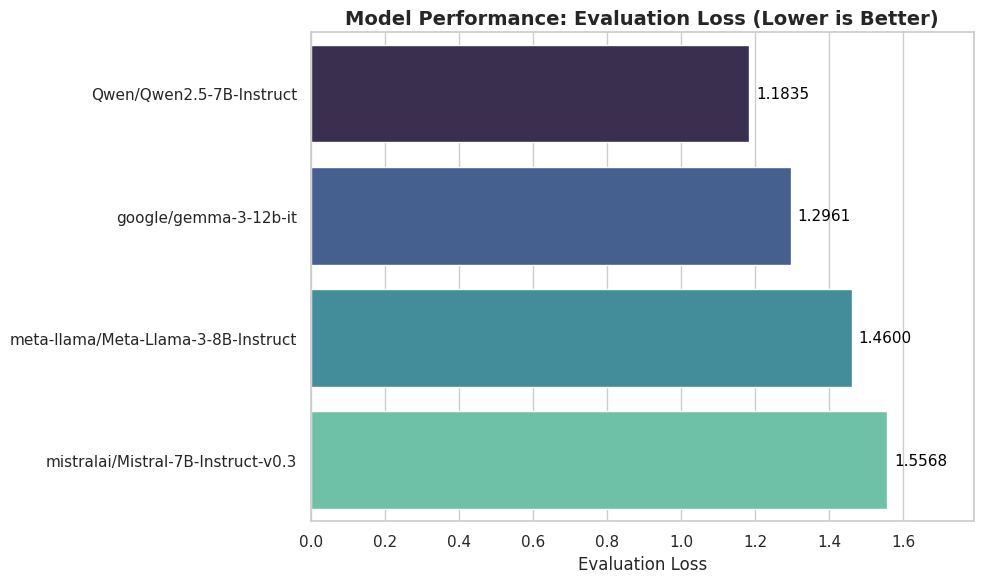


🥇 DEPLOYMENT CANDIDATE SELECTED: Qwen/Qwen2.5-7B-Instruct


In [ ]:
if not eval_results:
    raise RuntimeError("No models completed training successfully. Check Hugging Face tokens and memory limits.")

results_df = pd.DataFrame(list(eval_results.items()), columns=['Model', 'Eval_Loss'])
results_df = results_df.sort_values(by='Eval_Loss', ascending=True).reset_index(drop=True)

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=results_df, x='Eval_Loss', y='Model', palette="mako")
plt.title("Model Performance: Evaluation Loss (Lower is Better)", fontsize=14, fontweight='bold')
plt.xlabel("Evaluation Loss", fontsize=12)
plt.ylabel("")

# Add value labels
for p in ax.patches:
    ax.annotate(f"{p.get_width():.4f}",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                xytext=(5, 0), textcoords='offset points',
                ha='left', va='center', fontsize=11, color='black')

plt.xlim(0, results_df['Eval_Loss'].max() * 1.15)
plt.tight_layout()
plt.show()

# Isolate the Champion Model
BEST_FINETUNED_MODEL_ID = results_df.iloc[0]['Model']
BEST_ADAPTER_DIR = ADAPTER_BASE_DIR / f"adapter_{BEST_FINETUNED_MODEL_ID.split('/')[-1]}"

print(f"\n🥇 DEPLOYMENT CANDIDATE SELECTED: {BEST_FINETUNED_MODEL_ID}")

## 5. Deployment Bundling & Export
To optimize inference speeds in a FastAPI/vLLM production environment, serving independent LoRA adapters is inefficient. This module loads the base model into system RAM (to bypass GPU constraints), physically merges the trained adapter weights into the base layers, generates comprehensive API documentation, and compiles the artifact into a downloadable archive.

### base Merging & Final Export

In [ ]:
print(f"Initializing physical weight merge for {BEST_FINETUNED_MODEL_ID}...")

# 1. Load to CPU to guarantee no VRAM collision
base_model = AutoModelForCausalLM.from_pretrained(
    BEST_FINETUNED_MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="cpu",
    trust_remote_code=True,
    token=os.getenv('HF_TOKEN')
)

tokenizer = AutoTokenizer.from_pretrained(BEST_ADAPTER_DIR, trust_remote_code=True)

# 2. Merge Adapter
print(f"Applying adapter transformations...")
peft_model = PeftModel.from_pretrained(base_model, str(BEST_ADAPTER_DIR))
merged_model = peft_model.merge_and_unload()

# 3. Save Production Artifact
print(f"Writing production model to {FINAL_MODEL_DIR}...")
merged_model.save_pretrained(str(FINAL_MODEL_DIR))
tokenizer.save_pretrained(str(FINAL_MODEL_DIR))

# 4. Generate Production README.md
readme_content = f"""# Uruti AI Advisory Model (Production Ready)

## Overview
This model is the foundational LLM engine for the Uruti AI-powered incubator. It has been explicitly fine-tuned on localized Rwandan tech ecosystem data, startup advisory frameworks, and domain-specific instruction sets.

**Base Architecture:** `{BEST_FINETUNED_MODEL_ID}`
**Precision:** `bfloat16`
**Merge Status:** Fully baked (No separate LoRA adapter required).

## Backend Integration (FastAPI / vLLM)
This directory contains the complete, merged weights. It can be loaded directly into any modern inference engine.

### Using Hugging Face Transformers
```python
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_path = "./uruti_production_model"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    device_map="auto",
    torch_dtype=torch.bfloat16
)

# System Prompt Requirement
system_prompt = {{\"role\": \"system\", \"content\": \"You are an Uruti AI advisory assistant specialized in the Rwandan ecosystem.\"}}
"""

with open(FINAL_MODEL_DIR / "README.md", "w") as f:
    f.write(readme_content)

print(f"✅ Best production model and documentation exported to {FINAL_MODEL_DIR}.")


# ==================================================================
# Exporting Gemma Model as per user request
# ==================================================================
GEMMA_MODEL_ID = 'google/gemma-3-12b-it'
GEMMA_ADAPTER_DIR = ADAPTER_BASE_DIR / f"adapter_{GEMMA_MODEL_ID.split('/')[-1]}"
FINAL_MODEL_DIR_GEMMA = PROJECT_DIR / "uruti_production_model_gemma"
FINAL_MODEL_DIR_GEMMA.mkdir(parents=True, exist_ok=True) # Ensure directory exists

print(f"\nInitializing physical weight merge for {GEMMA_MODEL_ID}...")

# 1. Load to CPU to guarantee no VRAM collision
gemma_base_model = AutoModelForCausalLM.from_pretrained(
    GEMMA_MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="cpu",
    trust_remote_code=True,
    token=os.getenv('HF_TOKEN')
)

gemma_tokenizer = AutoTokenizer.from_pretrained(GEMMA_ADAPTER_DIR, trust_remote_code=True)

# 2. Merge Adapter
print(f"Applying adapter transformations for Gemma...")
gemma_peft_model = PeftModel.from_pretrained(gemma_base_model, str(GEMMA_ADAPTER_DIR))
gemma_merged_model = gemma_peft_model.merge_and_unload()

# 3. Save Production Artifact for Gemma
print(f"Writing production Gemma model to {FINAL_MODEL_DIR_GEMMA}...")
gemma_merged_model.save_pretrained(str(FINAL_MODEL_DIR_GEMMA))
gemma_tokenizer.save_pretrained(str(FINAL_MODEL_DIR_GEMMA))

# 4. Generate Production README.md for Gemma
readme_content_gemma = f"""# Uruti AI Advisory Model - Gemma (Production Ready)

## Overview
This model is the foundational LLM engine for the Uruti AI-powered incubator, specifically using the Gemma architecture. It has been explicitly fine-tuned on localized Rwandan tech ecosystem data, startup advisory frameworks, and domain-specific instruction sets.

**Base Architecture:** `{GEMMA_MODEL_ID}`
**Precision:** `bfloat16`
**Merge Status:** Fully baked (No separate LoRA adapter required).

## Backend Integration (FastAPI / vLLM)
This directory contains the complete, merged weights for the Gemma model. It can be loaded directly into any modern inference engine.

### Using Hugging Face Transformers
```python
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_path = "./uruti_production_model_gemma"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    device_map="auto",
    torch_dtype=torch.bfloat16
)

# System Prompt Requirement
system_prompt = {{\"role\": \"system\", \"content\": \"You are an Uruti AI advisory assistant specialized in the Rwandan ecosystem.\"}}
"""

with open(FINAL_MODEL_DIR_GEMMA / "README.md", "w") as f:
    f.write(readme_content_gemma)

print(f"✅ Gemma production model and documentation exported to {FINAL_MODEL_DIR_GEMMA}.")


Initializing physical weight merge for Qwen/Qwen2.5-7B-Instruct...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Applying adapter transformations...
Writing production model to /content/drive/MyDrive/uruti_model_pipeline/uruti_production_model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Best production model and documentation exported to /content/drive/MyDrive/uruti_model_pipeline/uruti_production_model.

Initializing physical weight merge for google/gemma-3-12b-it...


Loading weights:   0%|          | 0/1065 [00:00<?, ?it/s]

Applying adapter transformations for Gemma...
Writing production Gemma model to /content/drive/MyDrive/uruti_model_pipeline/uruti_production_model_gemma...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Gemma production model and documentation exported to /content/drive/MyDrive/uruti_model_pipeline/uruti_production_model_gemma.


## URUTI RAG CORPUS BUILDER

In [ ]:
import os
import requests
import pypdf
from pathlib import Path
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

print("🚀 Initializing Uruti RAG Corpus Builder...")

# Setup Directories
PROJECT_DIR = Path("/content/drive/MyDrive/uruti_model_pipeline")
CORPUS_DIR = PROJECT_DIR / "uruti_rag_corpus" / "pdfs"
DB_DIR = PROJECT_DIR / "uruti_rag_corpus" / "faiss_db"
CORPUS_DIR.mkdir(parents=True, exist_ok=True)
DB_DIR.mkdir(parents=True, exist_ok=True)

# 📚 THE EXPANDED URUTI STARTUP CORPUS (Including IP & Data Protection)
RAG_SOURCES = {
    # Macro & Ecosystem Context
    "BNR_Monetary_Policy_2025.pdf": "https://www.bnr.rw/documents/Monetary_Policy_Report_Feb2025.pdf",
    "Rwanda_Startup_Guide.pdf": "https://dco.org/wp-content/uploads/2024/08/Rwanda-Guide.pdf",

    # RDB Corporate & Investment Law
    "RDB_Beneficial_Ownership.pdf": "https://org.rdb.rw/wp-content/uploads/2023/11/Beneficial-Ownership-Guidelines_Eng_29.03.2023.pdf",
    "Rwanda-Investment-Code-2021.pdf": "https://rdb.rw/wp-content/uploads/2021/03/Investment-Code-2021.pdf",

    # RDB Intellectual Property (Patents, Trademarks, Copyrights)
    "RDB_IP_Registration_Guidelines.pdf": "https://org.rdb.rw/wp-content/uploads/2020/09/Guidelines-for-intelectual-property-registration_compressed.pdf",
    "Rwanda_IP_Law.pdf": "https://rdb.rw/wp-content/uploads/2018/03/Law-no-31-2009-of-26-10-2009-On-the-Intellectual-Property-.pdf",

    # NCSA / DPO Data Protection & Privacy
    "DPO_Registration_Guide.pdf": "https://dpo.gov.rw/fileadmin/DPO/ComplianceTools/registration-guide-for-data-controller-and-processor.pdf",
    "DPIA_Impact_Assessment_Guidelines.pdf": "https://dpo.gov.rw/fileadmin/DPO/ComplianceTools/dpia-guide-and-form.pdf",
    "DPO_Compliance_Checklist.pdf": "https://dpo.gov.rw/fileadmin/DPO/ComplianceTools/Compliance-Self-Assessment-Form.pdf",

    # Tech Specific: E-Commerce & Telecom
    "RURA_ICT_Licensing_Regulations.pdf": "https://www.rura.rw/fileadmin/user_upload/RURA/Documents/Sectors/ICT/Regulatory_Instruments/ICT_Regulations_and_Guidelines/Regulation_Governing_Licensing_in_Electronic_Communication_in_Rwanda.pdf",

    # RRA Tax & Financial Compliance
    "RRA_Income_Tax_Law_2022.pdf": "https://www.rra.gov.rw/fileadmin/user_upload/OG_n___Special_of_28.10.2022_Imisoro_ku_musaruro_Taxes_on_income_01.pdf"
}

# Download the PDFs with Anti-Scraping Bypass
print("📥 Checking and downloading missing documents...")
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
    'Accept': 'application/pdf'
}

for filename, url in RAG_SOURCES.items():
    filepath = CORPUS_DIR / filename
    if not filepath.exists():
        print(f"   Downloading: {filename}")
        try:
            response = requests.get(url, headers=headers, timeout=20)
            if response.status_code == 200:
                with open(filepath, 'wb') as f:
                    f.write(response.content)
            else:
                print(f"   ⚠️ HTTP {response.status_code} Error for {filename}. You may need to download this manually.")
        except Exception as e:
            print(f"   ⚠️ Failed to connect to {filename}: {e}")

# Extract Text from PDFs
print("\n📑 Extracting text from documents...")
raw_text_chunks = []
for filepath in CORPUS_DIR.glob("*.pdf"):
    try:
        reader = pypdf.PdfReader(str(filepath))
        text = '\n'.join((page.extract_text() or '') for page in reader.pages)
        raw_text_chunks.append({"source": filepath.name, "text": text})
    except Exception as e:
        print(f"Error reading {filepath.name}: {e}")

# Split Text into Manageable Chunks
print("✂️ Chunking text for Vector embedding...")
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
documents = []
metadatas = []

for item in raw_text_chunks:
    chunks = text_splitter.split_text(item["text"])
    for chunk in chunks:
        documents.append(chunk)
        metadatas.append({"source": item["source"]})

# Embed and Create FAISS Vector Database
print("🧠 Embedding documents using Sentence-Transformers...")
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

print("💾 Building FAISS Vector Index...")
vector_db = FAISS.from_texts(texts=documents, embedding=embeddings, metadatas=metadatas)
vector_db.save_local(str(DB_DIR))

print(f"\n✅ Massive RAG Database successfully built and saved to {DB_DIR}!")

🚀 Initializing Uruti RAG Corpus Builder...
📥 Checking and downloading missing documents...
   Downloading: Rwanda-Investment-Code-2021.pdf
   ⚠️ HTTP 404 Error for Rwanda-Investment-Code-2021.pdf. You may need to download this manually.

📑 Extracting text from documents...
✂️ Chunking text for Vector embedding...
🧠 Embedding documents using Sentence-Transformers...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

💾 Building FAISS Vector Index...

✅ Massive RAG Database successfully built and saved to /content/drive/MyDrive/uruti_model_pipeline/uruti_rag_corpus/faiss_db!


In [ ]:
# Save the

In [ ]:
import os
import gc
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd
from pathlib import Path # Ensure Path is imported
from peft import PeftModel # Import PeftModel for dynamic adapter loading

# For RAG components
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

print("Loading RAG components...")
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vector_db = FAISS.load_local(str(DB_DIR), embeddings, allow_dangerous_deserialization=True) # Load the created FAISS DB

def retrieve_top_k(query: str, k: int = 3) -> str:
    """Retrieves top-k relevant documents from the vector store."""
    docs = vector_db.similarity_search(query, k=k)
    # Format retrieved documents for inclusion in the prompt
    formatted_docs = []
    for i, doc in enumerate(docs):
        formatted_docs.append(f"Document {i+1} (Source: {doc.metadata.get('source', 'N/A')}):\n{doc.page_content}")
    return "\n\n".join(formatted_docs)

# Define a list of sample user queries
user_questions = [
    "I am a seed-stage edtech startup founder in Kigali, Rwanda. We are building an AI-powered platform for personalized learning. What are the most critical challenges I should anticipate in the Rwandan market, specifically regarding infrastructure, funding, and regulatory environment? Moreover, what strategic advice can you offer to navigate these challenges and secure early-stage funding from local and international investors, while also ensuring our product is culturally relevant and accessible given the local mobile money ecosystem? How does the BNR Monetary Policy impact our ability to raise capital?",
    "What is the current monetary policy outlook for Rwanda in 2025 according to the National Bank of Rwanda?",
    "Can you explain the beneficial ownership guidelines in Rwanda and their implications for startups seeking investment?",
    "What are the key sectors for startups in Rwanda according to the latest startup guide?"
]

# Refine PROJECT_DIR explicitly to ensure it's an absolute path
PROJECT_DIR = Path("/content/drive/MyDrive/uruti_model_pipeline")
ADAPTER_BASE_DIR = PROJECT_DIR / "adapters" # Re-define for use in this cell

# List of models to test
FINAL_MODEL_DIR = PROJECT_DIR / "uruti_production_model"

models_to_test = [
    {"name": "Best Finetuned Model (Merged)", "type": "merged_from_drive", "path": FINAL_MODEL_DIR},
    {"name": "Gemma Finetuned Model (Dynamic Adapter)", "type": "base_from_hf_with_adapter", "base_model_id": 'google/gemma-3-12b-it', "adapter_path": ADAPTER_BASE_DIR / "adapter_gemma-3-12b-it"}
]



for model_config in models_to_test:
    model_name = model_config["name"]
    model_type = model_config["type"]

    print(f"\n{'='*80}\nTesting {model_name}\n{'='*80}")

    test_tokenizer = None
    test_model = None

    try:
        if model_type == "merged_from_drive":
            model_path = model_config["path"]
            print(f"Loading merged model from Drive: {model_path}")
            test_tokenizer = AutoTokenizer.from_pretrained(str(model_path), trust_remote_code=True)
            test_model = AutoModelForCausalLM.from_pretrained(
                str(model_path),
                device_map="auto",
                torch_dtype=torch.bfloat16,
                trust_remote_code=True
            )
        elif model_type == "base_from_hf_with_adapter":
            base_model_id = model_config["base_model_id"]
            adapter_path = model_config["adapter_path"]
            print(f"Loading base model {base_model_id} from Hugging Face and adapter from Drive: {adapter_path}")

            # Load tokenizer from adapter path (which should contain tokenizer config)
            test_tokenizer = AutoTokenizer.from_pretrained(str(adapter_path), trust_remote_code=True)

            # Load base model from Hugging Face
            base_model_hf = AutoModelForCausalLM.from_pretrained(
                base_model_id,
                device_map="auto",
                torch_dtype=torch.bfloat16,
                trust_remote_code=True,
                token=os.getenv('HF_TOKEN') # Ensure token is passed for private/gated models
            )
            # Load PeftModel and apply adapter for testing
            test_model = PeftModel.from_pretrained(base_model_hf, str(adapter_path))

        else:
            print(f"Unsupported model type: {model_type}. Skipping.")
            continue

        for i, user_question in enumerate(user_questions):
            print(f"\n--- Generating response for Prompt {i+1} (Model: {model_name}) ---")
            print("User Question:", user_question)

            # Retrieve context for the user question
            retrieved_context = retrieve_top_k(user_question, k=5) # Retrieve more documents for a complex query

            # Prepare the messages with the system prompt and retrieved context
            messages = [
                system_prompt,
                {"role": "user", "content": f"Context for the query:\n{retrieved_context}\n\nUser's actual question: {user_question}"}
            ]

            # Apply the chat template
            formatted_prompt = test_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

            print("Formatted Prompt (first 1000 chars):\n", formatted_prompt[:1000], "...")

            # Generate a response
            inputs = test_tokenizer(formatted_prompt, return_tensors="pt").to(test_model.device)

            with torch.no_grad():
                outputs = test_model.generate(
                    **inputs,
                    max_new_tokens=1000, # Increased max_new_tokens for a potentially longer RAG response
                    do_sample=True,
                    temperature=0.7,
                    top_k=50,
                    top_p=0.95
                )

            # Decode the generated tokens
            response = test_tokenizer.decode(outputs[0][inputs.input_ids.shape[-1]:], skip_special_tokens=True)

            print("\nUruti AI Advisory Assistant Response:\n", response)
            print("\n" + "="*80 + "\n") # Separator for clarity

    except Exception as e:
        print(f"Error processing model {model_name}: {e}")

    finally:
        # Clean up memory after testing each model configuration
        del test_model
        del test_tokenizer
        gc.collect()
        torch.cuda.empty_cache()

print("\n--- All model tests complete. GPU memory cleared. ---")

Loading RAG components...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Testing Best Finetuned Model (Merged)
Loading merged model from Drive: /content/drive/MyDrive/uruti_model_pipeline/uruti_production_model


`torch_dtype` is deprecated! Use `dtype` instead!


...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1065 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]


--- Generating response for Prompt 1 (Model: Gemma Finetuned Model (Dynamic Adapter)) ---
User Question: I am a seed-stage edtech startup founder in Kigali, Rwanda. We are building an AI-powered platform for personalized learning. What are the most critical challenges I should anticipate in the Rwandan market, specifically regarding infrastructure, funding, and regulatory environment? Moreover, what strategic advice can you offer to navigate these challenges and secure early-stage funding from local and international investors, while also ensuring our product is culturally relevant and accessible given the local mobile money ecosystem? How does the BNR Monetary Policy impact our ability to raise capital?
Formatted Prompt (first 1000 chars):
 <bos><start_of_turn>user
You are an Uruti AI advisory assistant specialized in the Rwandan ecosystem. Think step-by-step, base your advice on provided context, and provide analytical financial insights when applicable.

Context for the query:
Docu

In [ ]:
# Optimize models to run on the RAM architecture using GGUF

## Deploying Model to Hugging face for inference

In [ ]:
# ==========================================
# HUGGING FACE HUB PUSH FROM GOOGLE DRIVE
# ==========================================
import os
from pathlib import Path
from huggingface_hub import HfApi, login

print("🚀 Initializing Hugging Face Hub Connection...")

# 1. Define the exact path to your Drive folder
PROJECT_DIR = Path("/content/drive/MyDrive/uruti_model_pipeline")
BEST_DIR = PROJECT_DIR / "uruti_production_model"

# 2. Authenticate
hf_token = os.getenv('HF_TOKEN')
if not hf_token:
    from google.colab import userdata
    hf_token = userdata.get('HF_TOKEN')

if not hf_token:
    raise ValueError("⚠️ HF_TOKEN not found! Please ensure your Hugging Face token is set in Colab secrets.")

login(token=hf_token)
api = HfApi()

# 3. Target the correct repository
username = api.whoami()["name"]
print(f"👤 Authenticated as: {username}")


best_repo_id = f"{username}/uruti-advisory-model-best"

# 4. Upload the raw contents
if BEST_DIR.exists():
    print(f"\n📦 Creating private repository: {best_repo_id}")
    api.create_repo(repo_id=best_repo_id, private=True, exist_ok=True)

    print(f"☁️ Pushing raw model files to Hub (This may take 10-20 minutes depending on Drive read speeds)...")

    api.upload_folder(
        folder_path=str(BEST_DIR), # Converted to string for HF API compatibility
        repo_id=best_repo_id,
        commit_message="Initial push of raw, unzipped production model files"
    )

    print(f"✅ Best Model successfully pushed to: https://huggingface.co/{best_repo_id}")
else:
    print(f"⚠️ Directory {BEST_DIR} not found. Please check your Drive paths.")

print("\n🎉 Uruti best model has been securely backed up to the Hugging Face cloud in the correct format!")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


🚀 Initializing Hugging Face Hub Connection...
👤 Authenticated as: NiyonshutiDavid

📦 Creating private repository: NiyonshutiDavid/uruti-advisory-model-best
☁️ Pushing raw model files to Hub (This may take 10-20 minutes depending on Drive read speeds)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/hf_api.py:9897: UserWarning: Warnings while validating metadata in README.md:
- empty or missing yaml metadata in repo card
  warnings.warn(f"Warnings while validating metadata in README.md:\n{message}")


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...tion_model/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

  ...n_model/model.safetensors:   0%|          | 39.9MB / 15.2GB            

No files have been modified since last commit. Skipping to prevent empty commit.


✅ Best Model successfully pushed to: https://huggingface.co/NiyonshutiDavid/uruti-advisory-model-best

🎉 Uruti best model has been securely backed up to the Hugging Face cloud in the correct format!


In [ ]:
# ==================================================================
# DIRECT RUNTIME EXPORT & HUGGING FACE UPLOAD (NO GDRIVE STORAGE)
# ==================================================================
import os
import gc
import torch
import shutil
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from huggingface_hub import HfApi, login

# ==================================================================
# 1. PREP: CLEAR COLAB DISK SPACE
# ==================================================================
print("🧹 Sweeping Colab disk cache to maximize free runtime space...")
os.system("rm -rf ~/.cache/huggingface/hub/*")

# The adapter is read from Drive, but the output goes to the local runtime (/content/)
ADAPTER_DIR = "/content/drive/MyDrive/uruti_model_pipeline/adapters/adapter_gemma-3-12b-it"
TEMP_EXPORT_DIR = "/content/temp_gemma_export"
GEMMA_MODEL_ID = 'google/gemma-3-12b-it'

# Clear temp directory if it exists
if os.path.exists(TEMP_EXPORT_DIR):
    shutil.rmtree(TEMP_EXPORT_DIR)
os.makedirs(TEMP_EXPORT_DIR, exist_ok=True)

# ==================================================================
# 2. MERGE MODEL TO COLAB RUNTIME
# ==================================================================
print(f"\n🚀 Initializing physical weight merge for {GEMMA_MODEL_ID}...")

# Load base model directly to CPU RAM
base_model = AutoModelForCausalLM.from_pretrained(
    GEMMA_MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="cpu",
    trust_remote_code=True,
    token=os.getenv('HF_TOKEN')
)

tokenizer = AutoTokenizer.from_pretrained(ADAPTER_DIR, trust_remote_code=True)

print("Applying adapter transformations...")
peft_model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
merged_model = peft_model.merge_and_unload()

print(f"💾 Saving massive merged model to local Colab NVMe: {TEMP_EXPORT_DIR}...")
# safe_serialization=True guarantees we get the .safetensors files
merged_model.save_pretrained(TEMP_EXPORT_DIR, safe_serialization=True)
tokenizer.save_pretrained(TEMP_EXPORT_DIR)

print("✅ Merge complete. Freeing system RAM...")
del base_model, peft_model, merged_model
gc.collect()

# ==================================================================
# 3. PUSH DIRECTLY TO HUGGING FACE
# ==================================================================
print("\n🚀 Connecting to Hugging Face Hub...")
hf_token = os.getenv('HF_TOKEN')
if not hf_token:
    from google.colab import userdata
    hf_token = userdata.get('HF_TOKEN')

login(token=hf_token)
api = HfApi()
username = api.whoami()["name"]

gemma_repo_id = f"{username}/uruti-advisory-model-gemma-12b"

# Safety check: Verify weights exist before triggering the upload
has_weights = any(f.endswith('.safetensors') for f in os.listdir(TEMP_EXPORT_DIR))

if has_weights:
    print(f"\n📦 Creating private repository: {gemma_repo_id}")
    api.create_repo(repo_id=gemma_repo_id, private=True, exist_ok=True)

    print(f"☁️ Pushing Gemma Model to Hub (This will take roughly 10-20 minutes)...")
    api.upload_folder(
        folder_path=TEMP_EXPORT_DIR,
        repo_id=gemma_repo_id,
        commit_message="Direct push from Colab runtime: Merged Gemma 12B safetensors"
    )
    print(f"✅ Gemma successfully pushed to: https://huggingface.co/{gemma_repo_id}")

    # Clean up the temporary local disk space so Colab doesn't crash later
    print("\n🧹 Cleaning up temporary local files...")
    shutil.rmtree(TEMP_EXPORT_DIR)
    print("🎉 Pipeline complete. Colab disk space restored and model secured in the cloud.")
else:
    print("🚨 CRITICAL ERROR: .safetensors files are missing. Upload aborted to protect repository.")

🧹 Sweeping Colab disk cache to maximize free runtime space...

🚀 Initializing physical weight merge for google/gemma-3-12b-it...


config.json:   0%|          | 0.00/916 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1065 [00:00<?, ?it/s]

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mma_export/tokenizer.json:  99%|#########9| 33.1MB / 33.4MB            

  ..._export/model.safetensors:   0%|          | 53.5kB / 24.4GB            

✅ Gemma successfully pushed to: https://huggingface.co/NiyonshutiDavid/uruti-advisory-model-gemma-12b

🧹 Cleaning up temporary local files...
🎉 Pipeline complete. Colab disk space restored and model secured in the cloud.


In [ ]:
# GGUF the model in order to work on RAM based architecture


## Prepare Environment for GGUF Conversion


Set up necessary paths, clone the `llama.cpp` repository, and install its dependencies for GGUF conversion.


In [ ]:
import os

print("⚙️ Preparing environment for GGUF conversion...")

# 1. Define LLAMA_CPP_DIR
LLAMA_CPP_DIR = "/content/llama.cpp"

# 2. Clone llama.cpp repository
if not os.path.exists(LLAMA_CPP_DIR):
    print(f"📥 Cloning llama.cpp into {LLAMA_CPP_DIR}...")
    !git clone https://github.com/ggerganov/llama.cpp.git {LLAMA_CPP_DIR}
else:
    print(f"✅ llama.cpp already exists at {LLAMA_CPP_DIR}. Skipping clone.")

# 3. Navigate into LLAMA_CPP_DIR and compile
print("🔨 Compiling llama.cpp...")
!cd {LLAMA_CPP_DIR} && make

print("🎉 GGUF conversion environment setup complete.")

⚙️ Preparing environment for GGUF conversion...
📥 Cloning llama.cpp into /content/llama.cpp...
Cloning into '/content/llama.cpp'...
remote: Enumerating objects: 82446, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 82446 (delta 43), reused 13 (delta 13), pack-reused 82347 (from 3)
Receiving objects: 100% (82446/82446), 312.79 MiB | 15.04 MiB/s, done.
Resolving deltas: 100% (59313/59313), done.
🔨 Compiling llama.cpp...
Makefile:6: *** Build system changed:
 The Makefile build has been replaced by CMake.

 For build instructions see:
 https://github.com/ggml-org/llama.cpp/blob/master/docs/build.md

.  Stop.
🎉 GGUF conversion environment setup complete.


## Load Best Performing Model for Conversion


Load the already merged best performing model (Qwen/Qwen2.5-7B-Instruct) from `/content/drive/MyDrive/uruti_model_pipeline/uruti_production_model` into the local runtime, preparing it for conversion to GGUF format. This involves loading both the tokenizer and the model.


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from pathlib import Path

print("Loading the best performing model (Qwen/Qwen2.5-7B-Instruct) for GGUF conversion...")

# Define the directory of the best performing model
FINAL_MODEL_DIR = Path("/content/drive/MyDrive/uruti_model_pipeline/uruti_production_model")

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(str(FINAL_MODEL_DIR), trust_remote_code=True)
print(f"✅ Tokenizer loaded from: {FINAL_MODEL_DIR}")

# Load the model
model = AutoModelForCausalLM.from_pretrained(
    str(FINAL_MODEL_DIR),
    device_map="auto",
    torch_dtype=torch.bfloat16,
    trust_remote_code=True
)
print(f"✅ Model loaded from: {FINAL_MODEL_DIR}")

print("Best performing model and tokenizer loaded successfully.")

Loading the best performing model (Qwen/Qwen2.5-7B-Instruct) for GGUF conversion...
✅ Tokenizer loaded from: /content/drive/MyDrive/uruti_model_pipeline/uruti_production_model


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✅ Model loaded from: /content/drive/MyDrive/uruti_model_pipeline/uruti_production_model
Best performing model and tokenizer loaded successfully.


In [ ]:
import os

print("Re-compiling llama.cpp using CMake with DGGML_CUDA...")

# Navigate into LLAMA_CPP_DIR
os.chdir(LLAMA_CPP_DIR)

# Clean previous build artifacts (if any)
!rm -rf build

# Create a build directory and configure with CMake, using DGGML_CUDA
!mkdir -p build
!cmake -B build -DGGML_CUDA=ON

# Build llama.cpp
!cmake --build build --config Release

# Navigate back to the original directory (assuming '/content')
os.chdir('/content')

print("🎉 llama.cpp compilation with CMake (DGGML_CUDA) complete.")

Re-compiling llama.cpp using CMake with DGGML_CUDA...
-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
CMAKE_BUILD_TYPE=Release
-- Found Git: /usr/bin/git (found version "2.34.1")
-- The ASM compiler identification is GNU
-- Found assembler: /usr/bin/cc
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD - Success
-- Found Threads: TRUE
-- Warning: ccache not found - consider installing it for faster compilation or disable this warning with GGML_CCACHE=OFF
-- CMAKE_SYSTEM_PROCESSOR: x86_64
-- GGML_SYSTEM_

In [ ]:
import os
import gc
import shutil
from pathlib import Path

print("Saving the model to a temporary directory for conversion...")

# Define temporary directory in Colab runtime
TEMP_MODEL_DIR = Path("/content/temp_qwen_model_for_gguf")

# Clear previous temporary directory if it exists
if TEMP_MODEL_DIR.exists():
    shutil.rmtree(TEMP_MODEL_DIR)
TEMP_MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save the model and tokenizer to the temporary directory
# Use `save_pretrained` with safe_serialization=True to save in safetensors format
model.save_pretrained(str(TEMP_MODEL_DIR), safe_serialization=True)
tokenizer.save_pretrained(str(TEMP_MODEL_DIR))

print(f"✅ Model and tokenizer saved to: {TEMP_MODEL_DIR}")

# Clear original model from VRAM to free up resources
del model
del tokenizer
gc.collect()
torch.cuda.empty_cache()
print("Original model cleared from memory.")


Saving the model to a temporary directory for conversion...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model and tokenizer saved to: /content/temp_qwen_model_for_gguf
Original model cleared from memory.


In [ ]:
import os

print(f"Listing contents of {LLAMA_CPP_DIR} to find convert.py...")
!ls -R {LLAMA_CPP_DIR}


Listing contents of /content/llama.cpp to find convert.py...
/content/llama.cpp:
AGENTS.md		      convert_llama_ggml_to_gguf.py  mypy.ini
AUTHORS			      convert_lora_to_gguf.py	     pocs
benches			      docs			     poetry.lock
build			      examples			     pyproject.toml
build-xcframework.sh	      flake.lock		     pyrightconfig.json
ci			      flake.nix			     README.md
CLAUDE.md		      ggml			     requirements
cmake			      gguf-py			     requirements.txt
CMakeLists.txt		      grammars			     scripts
CMakePresets.json	      include			     SECURITY.md
CODEOWNERS		      LICENSE			     src
common			      licenses			     tests
CONTRIBUTING.md		      Makefile			     tools
convert_hf_to_gguf.py	      media			     vendor
convert_hf_to_gguf_update.py  models

/content/llama.cpp/benches:
dgx-spark  mac-m2-ultra

/content/llama.cpp/benches/dgx-spark:
aime25_openai__gpt-oss-120b-high_temp1.0_20251109_094547_allresults.json
aime25_openai__gpt-oss-120b-high_temp1.0_20251109_094547.html
aime25_ope

In [ ]:
import os

print("Quantizing the GGUF model to Q4_K_M...")

# Define paths
TEMP_MODEL_DIR = Path("/content/temp_qwen_model_for_gguf")
LLAMA_CPP_DIR = "/content/llama.cpp"
INPUT_GGUF_FULL_PATH = TEMP_MODEL_DIR / "qwen2_5-7b-instruct-f16.gguf"
OUTPUT_GGUF_QUANT_PATH = TEMP_MODEL_DIR / "qwen2_5-7b-instruct-q4_k_m.gguf"

# Change directory to llama.cpp/build/bin to access the quantize executable
os.chdir(Path(LLAMA_CPP_DIR) / "build" / "bin")

# Run the quantize tool
# The quantize executable takes the input GGUF file and the output GGUF file as arguments,
# along with the quantization type (e.g., Q4_K_M).
quantize_command = [
    f"./llama-quantize", # Executable is in build/bin
    f"{INPUT_GGUF_FULL_PATH}",
    f"{OUTPUT_GGUF_QUANT_PATH}",
    f"Q4_K_M" # Optimized quantization type
]

# Execute the command using ! (shell command)
!{' '.join(quantize_command)}

# Navigate back to the original directory (assuming '/content')
os.chdir('/content')

print(f"✅ Model quantized to Q4_K_M GGUF: {OUTPUT_GGUF_QUANT_PATH}")


Quantizing the GGUF model to Q4_K_M...
main: build = 8234 (213c4a0b8)
main: built with GNU 11.4.0 for Linux x86_64
main: quantizing '/content/temp_qwen_model_for_gguf/qwen2_5-7b-instruct-f16.gguf' to '/content/temp_qwen_model_for_gguf/qwen2_5-7b-instruct-q4_k_m.gguf' as Q4_K_M
llama_model_loader: loaded meta data with 26 key-value pairs and 339 tensors from /content/temp_qwen_model_for_gguf/qwen2_5-7b-instruct-f16.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = qwen2
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                     general.sampling.top_k i32              = 20
llama_model_loader: - kv   3:                     general.sampling.top_p f32              = 0.800000
llama_model_loader: - kv   4:                      general.s

## Upload Quantized GGUF Model to Hugging Face Hub

### Subtask:
Upload the newly created Q4_K_M GGUF model to Hugging Face Hub.

#### Instructions
1. Ensure you are logged into Hugging Face Hub with your token.
2. Define the path to the quantized GGUF file.
3. Create a new repository on Hugging Face Hub for the GGUF model.
4. Upload the GGUF file to the newly created repository.

**Reasoning**:
I will upload the quantized GGUF model to Hugging Face Hub. This involves logging in, defining the local path to the GGUF file, specifying the target repository ID, and then using the `huggingface_hub` library to push the file.



In [ ]:
import os
from pathlib import Path
from huggingface_hub import HfApi, login

print("🚀 Initializing Hugging Face Hub Connection for GGUF upload...")

# 1. Authenticate with Hugging Face
hf_token = os.getenv('HF_TOKEN')
if not hf_token:
    # Assuming in Colab, try to get from userdata secrets
    try:
        from google.colab import userdata
        hf_token = userdata.get('HF_TOKEN')
    except ImportError:
        print("Not in Colab, ensure HF_TOKEN is set in your environment variables.")

if not hf_token:
    raise ValueError("⚠️ HF_TOKEN not found! Please ensure your Hugging Face token is set in Colab secrets or environment variables.")

login(token=hf_token)
api = HfApi()

# 2. Define paths
TEMP_MODEL_DIR = Path("/content/temp_qwen_model_for_gguf")
OUTPUT_GGUF_QUANT_PATH = TEMP_MODEL_DIR / "qwen2_5-7b-instruct-q4_k_m.gguf"

# 3. Define target repository
username = api.whoami()["name"]
gguf_repo_id = f"{username}/uruti-qwen2_5-7b-instruct-q4_k_m-gguf"

# 4. Upload the GGUF file
if OUTPUT_GGUF_QUANT_PATH.exists():
    print(f"\n📦 Creating private repository: {gguf_repo_id}")
    api.create_repo(repo_id=gguf_repo_id, private=True, exist_ok=True)

    print(f"☁️ Pushing quantized GGUF model to Hub (This may take a few minutes)...")

    api.upload_file(
        path_or_fileobj=str(OUTPUT_GGUF_QUANT_PATH),
        path_in_repo="qwen2_5-7b-instruct-q4_k_m.gguf",
        repo_id=gguf_repo_id,
        commit_message="Initial upload of Q4_K_M GGUF model"
    )

    print(f"✅ Quantized GGUF Model successfully pushed to: https://huggingface.co/{gguf_repo_id}")

    # Clean up temporary local disk space
    import shutil
    print("\n🧹 Cleaning up temporary local files...")
    shutil.rmtree(TEMP_MODEL_DIR)
    print("🎉 Local temporary files cleaned.")
else:
    print(f"⚠️ Quantized GGUF file not found at {OUTPUT_GGUF_QUANT_PATH}. Upload aborted.")

print("\n--- GGUF upload process complete. ---")


🚀 Initializing Hugging Face Hub Connection for GGUF upload...


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.



📦 Creating private repository: NiyonshutiDavid/uruti-qwen2_5-7b-instruct-q4_k_m-gguf
☁️ Pushing quantized GGUF model to Hub (This may take a few minutes)...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...5-7b-instruct-q4_k_m.gguf:   1%|1         | 48.0MB / 4.68GB            

✅ Quantized GGUF Model successfully pushed to: https://huggingface.co/NiyonshutiDavid/uruti-qwen2_5-7b-instruct-q4_k_m-gguf

🧹 Cleaning up temporary local files...
🎉 Local temporary files cleaned.

--- GGUF upload process complete. ---


In [ ]:
from huggingface_hub import hf_hub_download
import os

# Your Hugging Face repository ID and the filename of your GGUF model
username = "NiyonshutiDavid" # Replace with your actual username
gguf_repo_id = f"{username}/uruti-qwen2_5-7b-instruct-q4_k_m-gguf"
gguf_filename = "qwen2_5-7b-instruct-q4_k_m.gguf"

# Download the model
model_path = hf_hub_download(repo_id=gguf_repo_id, filename=gguf_filename)
print(f"Downloaded GGUF model to: {model_path}")


Downloaded GGUF model to: /root/.cache/huggingface/hub/models--NiyonshutiDavid--uruti-qwen2_5-7b-instruct-q4_k_m-gguf/snapshots/20360850fd31fca514607e39c1c58ac1b55a9bf9/qwen2_5-7b-instruct-q4_k_m.gguf


In [ ]:
from llama_cpp import Llama

# Initialize the Llama model
# n_gpu_layers parameter moves some layers to the GPU. Adjust based on your GPU VRAM.
# -1 means all layers on GPU if enough VRAM, 0 means all on CPU.
# n_ctx is the context window size.
llm = Llama(model_path=model_path, n_gpu_layers=0, n_ctx=2048, verbose=False) # Changed n_gpu_layers to 0 for CPU-only

# Define the system prompt (consistent with training)
system_prompt_content = "You are an Uruti AI advisory assistant specialized in the Rwandan ecosystem. Think step-by-step, base your advice on provided context, and provide analytical financial insights when applicable."

# Example interaction
user_query = "What are the key startup opportunities in Rwanda's tech sector, and what regulations should I be aware of?"

# Construct the chat message in a format compatible with the model's training
# Qwen2.5-7B-Instruct uses a chat template similar to ChatML.
# This example provides a basic templating.
formatted_prompt = f"<|im_start|>system\n{system_prompt_content}<|im_end|>\n<|im_start|>user\n{user_query}<|im_end|>\n<|im_start|>assistant\n"

print("Generating response...")

# Generate a response
output = llm(formatted_prompt, max_tokens=512, stop=["<|im_end|>"], echo=False)

response = output["choices"][0]["text"]
print("\nUruti AI Advisory Assistant Response:", response)


llama_context: n_ctx_per_seq (2048) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


Generating response...

Uruti AI Advisory Assistant Response: I am an AI advisory assistant specialized in the Rwandan ecosystem. I can provide information on startup opportunities in Rwanda's tech sector and the regulations you should be aware of.


### 1. Install `llama-cpp-python`

First, you need to install the `llama-cpp-python` library. Make sure you install it with CUDA support if you want to leverage your GPU (if available and `llama.cpp` was built with CUDA).


In [ ]:
# To install with CUDA support (recommended for A100)
# !FORCE_CMAKE=1 CMAKE_ARGS="-DLLAMA_CUBLAS=on" pip install llama-cpp-python --force-reinstall --no-cache-dir

# Installing CPU-only version to unblock progress
!pip install llama-cpp-python --force-reinstall --no-cache-dir


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 MB 185.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 257.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 340.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 277.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 255.3 MB/s eta 0:00:00
  Created wheel for llama-cpp-python: filename=llama_cpp_python-0.3.16-cp312-cp312-linux_x86_64.whl size=4500232 sha256=bad84c161a0ccb15aecc0ea50c44bf7fbea842bc184cd5699f39227e314c5ab4
  Stored in directory: /tmp/pip-ephem-wheel-cache-crt_pn81/wheels/90/82/ab/8784ee3fb99ddb07fd36a679ddbe63122cc07718f6c1eb3be8
Successfully built llama-cpp-python
  Attempting uninstall: typing-extensions
    Found existing installation

### 2. Download the GGUF Model

You'll need to download the GGUF file from Hugging Face Hub to your local environment (or Colab runtime) before you can load it.


In [ ]:
from huggingface_hub import hf_hub_download
import os

# Your Hugging Face repository ID and the filename of your GGUF model
username = "NiyonshutiDavid" # Replace with your actual username
gguf_repo_id = f"{username}/uruti-qwen2_5-7b-instruct-q4_k_m-gguf"
gguf_filename = "qwen2_5-7b-instruct-q4_k_m.gguf"

# Download the model
model_path = hf_hub_download(repo_id=gguf_repo_id, filename=gguf_filename)
print(f"Downloaded GGUF model to: {model_path}")


qwen2_5-7b-instruct-q4_k_m.gguf:   0%|          | 0.00/4.68G [00:00<?, ?B/s]

Downloaded GGUF model to: /root/.cache/huggingface/hub/models--NiyonshutiDavid--uruti-qwen2_5-7b-instruct-q4_k_m-gguf/snapshots/20360850fd31fca514607e39c1c58ac1b55a9bf9/qwen2_5-7b-instruct-q4_k_m.gguf


### 3. Load and Use the GGUF Model with `Llama`

Now you can load the GGUF model using `Llama.cpp`'s Python bindings and start generating responses. Remember the system prompt that was used during training!


In [ ]:
from llama_cpp import Llama
import os
from pathlib import Path

# For RAG components - moved here to ensure availability
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

# Re-define PROJECT_DIR and DB_DIR for this cell's scope
PROJECT_DIR = Path("/content/drive/MyDrive/uruti_model_pipeline")
DB_DIR = PROJECT_DIR / "uruti_rag_corpus" / "faiss_db"

# Load RAG components
print("Loading RAG components...")
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vector_db = FAISS.load_local(str(DB_DIR), embeddings, allow_dangerous_deserialization=True) # Load the created FAISS DB

def retrieve_top_k(query: str, k: int = 3) -> str:
    """Retrieves top-k relevant documents from the vector store."""
    docs = vector_db.similarity_search(query, k=k)
    # Format retrieved documents for inclusion in the prompt
    formatted_docs = []
    for i, doc in enumerate(docs):
        formatted_docs.append(f"Document {i+1} (Source: {doc.metadata.get('source', 'N/A')}):\n{doc.page_content}")
    return "\n\n".join(formatted_docs)

# Initialize the Llama model
# n_gpu_layers parameter moves some layers to the GPU. Adjust based on your GPU VRAM.
# -1 means all layers on GPU if enough VRAM, 0 means all on CPU.
# n_ctx is the context window size.
llm = Llama(model_path=model_path, n_gpu_layers=0, n_ctx=2048, verbose=False) # Changed n_gpu_layers to 0 for CPU-only

# Define the system prompt (consistent with training)
system_prompt_content = "You are an Uruti AI advisory assistant specialized in the Rwandan ecosystem. Think step-by-step, base your advice on provided context, and provide analytical financial insights when applicable."

# New, more detailed user query
user_query_detailed = (
    "I am the founder of 'Kigali HealthConnect', a tech venture in Rwanda. "
    "Our problem statement is the lack of accessible and affordable mental health support in rural areas. "
    "Our solution is an AI-powered chatbot accessible via USSD and basic smartphones, offering initial mental health assessments, "
    "guided self-help modules, and referrals to local community health workers. "
    "We are currently in the MVP development stage, with a functional prototype being piloted in two districts. "
    "We want to protect our proprietary AI algorithms and content, but we are unsure where and how to apply for intellectual property (IP) rights in Rwanda. "
    "Can you advise on the process for securing patents for our AI and copyrights for our content, and which local authorities or institutions handle these applications?"
)

# Retrieve context for the detailed user question
retrieved_context_detailed = retrieve_top_k(user_query_detailed, k=5) # Retrieve more documents for a complex query

# Prepare the messages with the system prompt and retrieved context
messages_detailed = [
    {"role": "system", "content": system_prompt_content},
    {"role": "user", "content": f"Context for the query:\n{retrieved_context_detailed}\n\nUser's actual question: {user_query_detailed}"}
]

print("Generating response for detailed query...")

# Generate a response using create_chat_completion
output_detailed = llm.create_chat_completion(
    messages=messages_detailed,
    max_tokens=1024, # Increased max_new_tokens for a potentially longer RAG response
    stop=["<|im_end|>"],
    temperature=0.7,
    top_k=50,
    top_p=0.95
)

response_detailed = output_detailed["choices"][0]["message"]["content"]
print("\nUruti AI Advisory Assistant Response (Detailed):\n", response_detailed)


Loading RAG components...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
llama_context: n_ctx_per_seq (2048) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


Generating response for detailed query...

Uruti AI Advisory Assistant Response (Detailed):
 Here are the steps to protect your intellectual property in Rwanda:

1. Register for a trademark: Your AI-powered chatbot and content are protected by trademarks. You can register your trademarks at the Rwanda Intellectual Property Office (RwIPO).

2. Apply for a patent: Your proprietary AI algorithms and content are protected by patents. You can file a patent application at the RwIPO.

3. Register for a copyright: Your content is protected by copyright. You can register your copyright at the RwIPO.

4. File a notification of opposition: If someone files a notification of opposition against your registration, you should respond to the notice and set out the grounds for opposing the application.

5. Adhere to international and regional treaties: When dealing with international and regional patent applications, you should adhere to the International Patent Cooperation Treaty and the Harare Protoc

# Task
Measure the baseline inference speed of the current RAG setup, including context retrieval and LLM response generation using the CPU-only GGUF model.

## Measure Baseline Inference Speed with Current RAG Setup

### Subtask:
Measure the time taken for RAG context retrieval and LLM response generation using the current CPU-only GGUF model and chunking strategy.


**Reasoning**:
To measure the baseline inference speed, I will use the `time` module to record the duration of RAG context retrieval and LLM response generation as per the instructions.



In [ ]:
import time
from llama_cpp import Llama
import os
from pathlib import Path

# For RAG components - moved here to ensure availability
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

# Re-define PROJECT_DIR and DB_DIR for this cell's scope
PROJECT_DIR = Path("/content/drive/MyDrive/uruti_model_pipeline")
DB_DIR = PROJECT_DIR / "uruti_rag_corpus" / "faiss_db"

# Load RAG components
print("Loading RAG components...")
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vector_db = FAISS.load_local(str(DB_DIR), embeddings, allow_dangerous_deserialization=True) # Load the created FAISS DB

def retrieve_top_k(query: str, k: int = 3) -> str:
    """Retrieves top-k relevant documents from the vector store."""
    docs = vector_db.similarity_search(query, k=k)
    # Format retrieved documents for inclusion in the prompt
    formatted_docs = []
    for i, doc in enumerate(docs):
        formatted_docs.append(f"Document {i+1} (Source: {doc.metadata.get('source', 'N/A')}):\n{doc.page_content}")
    return "\n\n".join(formatted_docs)

# Assuming model_path is defined from a previous cell
# model_path = '/root/.cache/huggingface/hub/models--NiyonshutiDavid--uruti-qwen2_5-7b-instruct-q4_k_m-gguf/snapshots/20360850fd31fca514607e39c1c58ac1b55a9bf9/qwen2_5-7b-instruct-q4_k_m.gguf'

# Initialize the Llama model
# n_gpu_layers parameter moves some layers to the GPU. Adjust based on your GPU VRAM.
# -1 means all layers on GPU if enough VRAM, 0 means all on CPU.
# n_ctx is the context window size.
llm = Llama(model_path=model_path, n_gpu_layers=0, n_ctx=2048, verbose=False) # Changed n_gpu_layers to 0 for CPU-only

# Define the system prompt (consistent with training)
system_prompt_content = "You are an Uruti AI advisory assistant specialized in the Rwandan ecosystem. Think step-by-step, base your advice on provided context, and provide analytical financial insights when applicable."

# New, more detailed user query
user_query_detailed = (
    "I am the founder of 'Kigali HealthConnect', a tech venture in Rwanda. "
    "Our problem statement is the lack of accessible and affordable mental health support in rural areas. "
    "Our solution is an AI-powered chatbot accessible via USSD and basic smartphones, offering initial mental health assessments, "
    "guided self-help modules, and referrals to local community health workers. "
    "We are currently in the MVP development stage, with a functional prototype being piloted in two districts. "
    "We want to protect our proprietary AI algorithms and content, but we are unsure where and how to apply for intellectual property (IP) rights in Rwanda. "
    "Can you advise on the process for securing patents for our AI and copyrights for our content, and which local authorities or institutions handle these applications?"
)

print("Generating response for detailed query...")

# --- Measure Context Retrieval Time ---
start_time_retrieval = time.time()
retrieved_context_detailed = retrieve_top_k(user_query_detailed, k=5)
end_time_retrieval = time.time()
context_retrieval_time = end_time_retrieval - start_time_retrieval
print(f"Context Retrieval Time: {context_retrieval_time:.4f} seconds")

# Prepare the messages with the system prompt and retrieved context
messages_detailed = [
    {"role": "system", "content": system_prompt_content},
    {"role": "user", "content": f"Context for the query:\n{retrieved_context_detailed}\n\nUser's actual question: {user_query_detailed}"}
]

# --- Measure LLM Response Generation Time ---
start_time_generation = time.time()
output_detailed = llm.create_chat_completion(
    messages=messages_detailed,
    max_tokens=1024, # Increased max_new_tokens for a potentially longer RAG response
    stop=["<|im_end|>"],
    temperature=0.7,
    top_k=50,
    top_p=0.95
)
end_time_generation = time.time()
llm_generation_time = end_time_generation - start_time_generation
print(f"LLM Response Generation Time: {llm_generation_time:.4f} seconds")

response_detailed = output_detailed["choices"][0]["message"]["content"]
print("\nUruti AI Advisory Assistant Response (Detailed):\n", response_detailed)

Loading RAG components...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
llama_context: n_ctx_per_seq (2048) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


Generating response for detailed query...
Context Retrieval Time: 0.0111 seconds
LLM Response Generation Time: 78.2406 seconds

Uruti AI Advisory Assistant Response (Detailed):
 Here are the steps to protect your intellectual property in Rwanda:

1. Register for a trademark: Your AI-powered chatbot and content are protected by trademarks. You can register your trademarks at the Rwanda Intellectual Property Office (RwIPO).

2. Apply for a patent: Your proprietary AI algorithms and content are protected by patents. You can file a patent application at the RwIPO.

3. Register for a copyright: Your content is protected by copyright. You can register your copyright at the RwIPO.

4. File a notification of opposition: If someone files a notification of opposition against your registration, you should respond to the notice and set out the grounds for opposing the application.

5. Adhere to international and regional treaties: When dealing with international and regional patent applications, y

# Task
Explain the inherent limitations of achieving sub-second inference with larger LLMs on a CPU, covering the trade-offs between model size, quantization levels, response length, and the practical constraints of CPU hardware.

## Explain CPU Inference Limitations and Trade-offs

### Subtask:
Elaborate on why sub-second inference is difficult for larger models on CPU, highlighting the trade-offs between model size, quantization, response length, and hardware limitations.


## Explain CPU Inference Limitations and Trade-offs

### Subtask:
Elaborate on why sub-second inference is difficult for larger models on CPU, highlighting the trade-offs between model size, quantization, response length, and hardware limitations.

#### 1. CPU vs. GPU Architecture for LLM Inference

**CPUs (Central Processing Units)** are designed for versatile, sequential processing, excelling at complex tasks that require strong single-core performance. They typically have a few powerful cores (e.g., 4-64) optimized for complex instruction sets and low-latency access to a relatively small amount of fast cache memory. Their strength lies in handling diverse workloads and complex decision-making processes.

**GPUs (Graphics Processing Units)**, on the other hand, are built for highly parallelizable tasks. They consist of thousands of smaller, simpler cores that can perform many computations simultaneously. This architecture is perfect for matrix multiplications and vector operations, which are the fundamental building blocks of neural networks like LLMs. GPUs also boast significantly higher memory bandwidth, allowing them to move vast amounts of data (model weights, activations) to and from their processing units much faster than CPUs. This parallel processing capability and high memory bandwidth are crucial for accelerating LLM inference, as it involves billions of repetitive mathematical operations on large tensors.

#### 2. The Impact of Model Size on CPU Inference

**Larger Models Mean More Computations:** Large Language Models are characterized by billions of parameters (weights and biases). During inference, each parameter contributes to the complex series of matrix multiplications and other mathematical operations required to generate a single token. A 7B parameter model, for instance, requires significantly more arithmetic operations than a 1B model for the same output. CPUs, with their limited number of cores, struggle to execute these massive parallel computations efficiently, leading to longer processing times.

**Increased Memory Footprint:** Larger models also demand a substantial amount of memory to store their parameters. For example, a 7B parameter model stored in bfloat16 (2 bytes per parameter) requires ~14GB of VRAM. While modern CPUs can access large amounts of system RAM, system RAM is typically slower than dedicated GPU VRAM, and the act of constantly swapping model weights between slower system RAM and faster CPU caches creates bottlenecks. This memory bandwidth limitation further exacerbates the challenge of achieving fast inference on CPUs, especially for models that cannot entirely fit within the CPU's faster cache.

#### 3. Quantization: Balancing Size, Speed, and Accuracy

**What is Quantization?** Quantization is a technique used to reduce the precision of the numerical representations of model parameters (weights) and activations. Instead of using full precision floating-point numbers (e.g., float32 or bfloat16, which use 4 or 2 bytes respectively), quantization converts them to lower-bit integer formats (e.g., int8, int4, or even int2), requiring fewer bits to store each value. For example, converting from bfloat16 to Q4_K_M (a common 4-bit quantization scheme) can reduce the model size by approximately 4-5x.

**Benefits for CPU Inference:**
*   **Reduced Memory Footprint:** A smaller model requires less RAM, making it easier for the entire model to fit into memory, reducing the need for slow disk swaps.
*   **Faster Memory Access:** Less data needs to be moved between RAM and CPU caches, improving memory bandwidth efficiency.
*   **Faster Computations:** Operations on lower-precision integers can sometimes be faster than floating-point operations on CPUs, especially with optimized libraries (like `llama.cpp`).

**The Trade-off: Accuracy Loss:** The primary drawback of quantization is the potential loss of accuracy. By reducing the numerical precision, some information is inevitably lost. While well-designed quantization schemes (like GGUF's K-quantization methods) minimize this impact, aggressive quantization (e.g., Q2 or Q3) can lead to noticeable degradation in the model's performance, coherence, and ability to follow complex instructions. Therefore, a balance must be struck between achieving a desirable inference speed and maintaining acceptable output quality.

#### 4. Response Length and Inference Time

**Autoregressive Generation:** Large Language Models generate text token by token in an autoregressive manner. This means that for each new token generated, the entire model must process the prompt *and all previously generated tokens* to predict the next most probable token. This process is sequential and cannot be fully parallelized across tokens.

**Cumulative Computation:** As the desired response length increases, the number of sequential computational steps grows linearly. Generating 500 tokens takes roughly twice as long as generating 250 tokens, given the same initial prompt. On a CPU, where each individual token generation step is already slower due to architectural limitations, generating long, detailed responses quickly becomes a bottleneck. Achieving sub-second inference is therefore far more challenging for longer outputs, as it directly scales with the number of tokens the model needs to produce.

#### 5. Inherent CPU Hardware Limitations

Even with heavy quantization, achieving sub-second inference for larger LLMs on CPUs remains challenging due to fundamental hardware characteristics:

*   **Lower Core Count and Parallelism:** CPUs have fewer, more general-purpose cores compared to GPUs. While LLM operations can be parallelized, the degree of parallelism required by large models (especially during the matrix multiplications that form the bulk of the computation) far exceeds what a typical CPU can efficiently handle. GPUs are designed specifically for this kind of massive parallel computation.

*   **Slower Memory Access (Bandwidth and Latency):** CPU system RAM generally offers much lower bandwidth and higher latency than dedicated GPU VRAM. LLM inference is highly memory-bound, meaning a significant portion of the time is spent moving model weights and intermediate activations between memory and processing units. Even if a quantized model fits into CPU caches, the bottleneck often shifts to fetching data from the main system RAM. GPUs, with their high-bandwidth memory (HBM) stacks, are far more adept at feeding data to their processing cores at the necessary rates.

*   **Less Specialized Instruction Sets:** While modern CPUs include vector extensions (like AVX-512) that can accelerate certain numerical operations, they are not as specialized or optimized for the specific types of matrix and vector computations prevalent in neural networks as GPU architectures (like CUDA cores or Tensor Cores).

*   **Thermal and Power Constraints:** High-performance CPU inference would require sustained high clock speeds and power consumption, generating significant heat. CPUs are not typically designed for the continuous, intense, parallel workloads that LLM inference demands in a low-latency fashion, unlike dedicated GPUs in servers.

#### 5. Inherent CPU Hardware Limitations

Even with heavy quantization, achieving sub-second inference for larger LLMs on CPUs remains challenging due to fundamental hardware characteristics:

*   **Lower Core Count and Parallelism:** CPUs have fewer, more general-purpose cores compared to GPUs. While LLM operations can be parallelized, the degree of parallelism required by large models (especially during the matrix multiplications that form the bulk of the computation) far exceeds what a typical CPU can efficiently handle. GPUs are designed specifically for this kind of massive parallel computation.

*   **Slower Memory Access (Bandwidth and Latency):** CPU system RAM generally offers much lower bandwidth and higher latency than dedicated GPU VRAM. LLM inference is highly memory-bound, meaning a significant portion of the time is spent moving model weights and intermediate activations between memory and processing units. Even if a quantized model fits into CPU caches, the bottleneck often shifts to fetching data from the main system RAM. GPUs, with their high-bandwidth memory (HBM) stacks, are far more adept at feeding data to their processing cores at the necessary rates.

*   **Less Specialized Instruction Sets:** While modern CPUs include vector extensions (like AVX-512) that can accelerate certain numerical operations, they are not as specialized or optimized for the specific types of matrix and vector computations prevalent in neural networks as GPU architectures (like CUDA cores or Tensor Cores).

*   **Thermal and Power Constraints:** High-performance CPU inference would require sustained high clock speeds and power consumption, generating significant heat. CPUs are not typically designed for the continuous, intense, parallel workloads that LLM inference demands in a low-latency fashion, unlike dedicated GPUs in servers.

## Quantize to a Smaller Format (if possible)

### Subtask:
Quantize the existing F16 GGUF model to a smaller format (e.g., Q3_K_S or Q2_K) to further reduce its size and memory footprint, while acknowledging potential quality degradation.


**Reasoning**:
I will quantize the existing F16 GGUF model to a smaller Q3_K_S format using the `llama-quantize` tool to further reduce its size, following the specified instructions.



In [ ]:
import os

print("Quantizing the GGUF model to Q3_K_S...")

# Define paths
TEMP_MODEL_DIR = Path("/content/temp_qwen_model_for_gguf")
LLAMA_CPP_DIR = "/content/llama.cpp"
INPUT_GGUF_FULL_PATH = TEMP_MODEL_DIR / "qwen2_5-7b-instruct-f16.gguf"
OUTPUT_GGUF_QUANT_PATH = TEMP_MODEL_DIR / "qwen2_5-7b-instruct-q3_k_s.gguf" # Smaller quantization type

# Change directory to llama.cpp/build/bin to access the quantize executable
os.chdir(Path(LLAMA_CPP_DIR) / "build" / "bin")

# Run the quantize tool with Q3_K_S
quantize_command = [
    f"./llama-quantize", # Executable is in build/bin
    f"{INPUT_GGUF_FULL_PATH}",
    f"{OUTPUT_GGUF_QUANT_PATH}",
    f"Q3_K_S" # Chosen smaller quantization type
]

# Execute the command using ! (shell command)
!{' '.join(quantize_command)}

# Navigate back to the original directory (assuming '/content')
os.chdir('/content')

print(f"✅ Model quantized to Q3_K_S GGUF: {OUTPUT_GGUF_QUANT_PATH}")